# Lab Example: BG/NBD & Gamma-Gamma với dữ liệu giả

## Mục tiêu

- Làm ví dụ đơn giản cách dùng BG/NBD & Gamma-Gamma để tính CLV.
- Sử dụng dữ liệu giao dịch **giả lập** (synthetic) cho một nhóm khách hàng nhỏ.
- Tính CLV trong 12 tháng tới cho từng khách hàng.

## 1. Cài đặt & import thư viện

In [14]:
# Cài đặt (nếu cần) & import thư viện
# !pip install lifetimes

import numpy as np
import pandas as pd
from datetime import datetime, timedelta

from lifetimes import BetaGeoFitter
from lifetimes import GammaGammaFitter
from lifetimes.utils import summary_data_from_transaction_data


## 2. Tạo dữ liệu giao dịch **giả lập**

Ở ví dụ này, ta sẽ tạo dữ liệu giao dịch đơn giản cho khoảng 50 khách hàng:

- Mỗi khách có từ 1–10 giao dịch.
- Ngày giao dịch được rải ngẫu nhiên trong 2 năm gần đây.
- Giá trị đơn hàng (amount) được sinh ngẫu nhiên theo phân phối log-normal.

In [15]:
np.random.seed(42)

n_customers = 200  # tăng số khách hàng để mô hình hội tụ tốt hơn
max_txns_per_customer = 15

customer_ids = []
dates = []
amounts = []

today = datetime(2024, 1, 1)
start_date = today - timedelta(days=730)  # khoảng 2 năm trước

for cust_id in range(1, n_customers + 1):
    # Tạo phân phối tần suất mua hợp lý hơn (nhiều khách mua ít, ít khách mua nhiều)
    n_txn = np.random.poisson(lam=3) + 1  # Poisson với lambda=3, +1 để đảm bảo >= 1
    n_txn = min(n_txn, max_txns_per_customer)  # giới hạn tối đa
    
    # random ngày trong khoảng [start_date, today), phân bố đều hơn
    random_days = np.random.uniform(0, (today - start_date).days, size=n_txn)
    txn_dates = [start_date + timedelta(days=int(d)) for d in random_days]
    txn_dates = sorted(txn_dates)

    # giá trị đơn hàng theo log-normal (đảm bảo > 0)
    txn_amounts = np.random.lognormal(mean=3.0, sigma=0.5, size=n_txn)

    for d, a in zip(txn_dates, txn_amounts):
        customer_ids.append(cust_id)
        dates.append(d)
        amounts.append(a)

transactions = pd.DataFrame({
    'customer_id': customer_ids,
    'date': dates,
    'amount': amounts
})

transactions.head()

,customer_id,date,amount
0,1,2022-02-12,15.883214
1,1,2022-04-24,26.345040
2,1,2023-03-15,15.931386
3,1,2023-06-01,15.912980
4,1,2023-09-25,22.668610


## 3. Chuyển sang dạng summary cho BG/NBD & Gamma-Gamma

Ta cần bảng summary với các cột chuẩn:

- `frequency`: số lần mua lại (số giao dịch - 1).
- `recency`: khoảng thời gian (tính bằng đơn vị thời gian) từ giao dịch đầu tiên đến giao dịch gần nhất.
- `T`: khoảng thời gian từ giao dịch đầu tiên đến thời điểm quan sát (observation period).
- `monetary_value`: giá trị trung bình mỗi giao dịch (chỉ tính cho khách có `frequency` > 0).

In [16]:
observation_period_end = today

summary = summary_data_from_transaction_data(
    transactions,
    customer_id_col='customer_id',
    datetime_col='date',
    monetary_value_col='amount',
    observation_period_end=observation_period_end,
    freq='D'  # đơn vị ngày
)

summary.head()

,frequency,recency,T,monetary_value
customer_id,,,,
1,4.0,590.0,688.0,20.214504
2,3.0,360.0,517.0,15.308710
3,2.0,114.0,140.0,16.117355
4,2.0,638.0,705.0,16.602719
5,6.0,639.0,697.0,20.397343


## 4. Huấn luyện mô hình BG/NBD & Gamma-Gamma

In [17]:
# BG/NBD cho tần suất mua
# Thêm penalizer để tránh lỗi convergence với dữ liệu nhỏ
bgf = BetaGeoFitter(penalizer_coef=0.01)
bgf.fit(summary['frequency'], summary['recency'], summary['T'])

# Gamma-Gamma cho giá trị đơn hàng
summary_nonzero = summary[summary['monetary_value'] > 0]
ggf = GammaGammaFitter(penalizer_coef=0.01)
ggf.fit(summary_nonzero['frequency'], summary_nonzero['monetary_value'])

summary_nonzero.head()

,frequency,recency,T,monetary_value
customer_id,,,,
1,4.0,590.0,688.0,20.214504
2,3.0,360.0,517.0,15.308710
3,2.0,114.0,140.0,16.117355
4,2.0,638.0,705.0,16.602719
5,6.0,639.0,697.0,20.397343


## 5. Tính CLV trong 12 tháng tới

Ta sẽ:

- Dự báo số lần mua trong 12 tháng tới với BG/NBD.
- Kết hợp với giá trị đơn hàng từ Gamma-Gamma.
- Tính CLV (giá trị chiết khấu) với discount rate đơn giản, ví dụ 1%/tháng.

In [18]:
time_horizon_months = 12
discount_rate = 0.01  # 1%/tháng

clv = ggf.customer_lifetime_value(
    bgf,  # mô hình BG/NBD để dự báo số lần mua
    summary_nonzero['frequency'],
    summary_nonzero['recency'],
    summary_nonzero['T'],
    summary_nonzero['monetary_value'],
    time=time_horizon_months,
    discount_rate=discount_rate
)

summary_clv = summary_nonzero.join(clv.rename('CLV_12m'))
summary_clv.head()

,frequency,recency,T,monetary_value,CLV_12m
customer_id,,,,,
1,4.0,590.0,688.0,20.214504,39.514786
2,3.0,360.0,517.0,15.308710,30.654182
3,2.0,114.0,140.0,16.117355,42.944588
4,2.0,638.0,705.0,16.602719,23.737689
5,6.0,639.0,697.0,20.397343,50.714259


## 6. Xếp hạng khách hàng theo CLV

In [19]:
summary_clv_sorted = summary_clv.sort_values('CLV_12m', ascending=False)
summary_clv_sorted.head(10)

,frequency,recency,T,monetary_value,CLV_12m
customer_id,,,,,
43,2.0,469.0,546.0,64.397055,96.949521
144,5.0,512.0,663.0,42.654522,95.052288
35,3.0,164.0,201.0,34.098394,93.681350
112,7.0,602.0,653.0,32.711401,92.711014
169,3.0,328.0,407.0,43.114169,91.337464
16,6.0,532.0,552.0,31.618302,88.198511
155,6.0,700.0,711.0,34.901325,84.598048
88,5.0,447.0,536.0,33.304731,83.604372
76,2.0,308.0,514.0,50.303549,78.772705


In [20]:
# 7. Phân nhóm CLV thành 3 nhóm và visualize

# Tạo 3 nhóm CLV: Low, Medium, High theo 3 quantile
summary_clv['CLV_segment'] = pd.qcut(summary_clv['CLV_12m'], 3,
                                     labels=['Low', 'Medium', 'High'])

# Xem nhanh số lượng khách hàng trong mỗi nhóm
segment_counts = summary_clv['CLV_segment'].value_counts().sort_index()
segment_counts


CLV_segment
Low       64
Medium    63
High      64
Name: count, dtype: int64

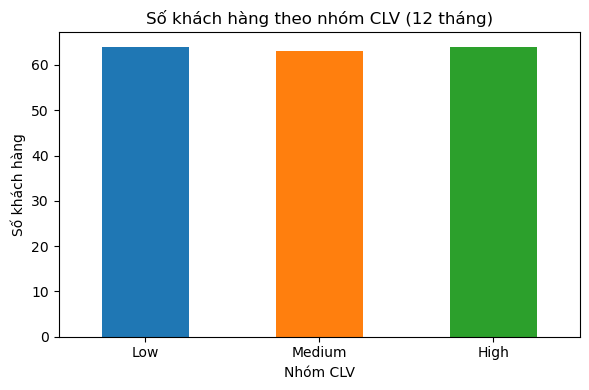

In [21]:
# Visualize phân bổ số khách hàng theo 3 nhóm CLV
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
segment_counts.plot(kind='bar', color=['tab:blue', 'tab:orange', 'tab:green'])
plt.title('Số khách hàng theo nhóm CLV (12 tháng)')
plt.xlabel('Nhóm CLV')
plt.ylabel('Số khách hàng')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()